In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

base = Path.cwd().parent

raw = base / "data" / "raw"
processed = base / "data" / "processed"
charts = base / "reports" / "charts"

charts.mkdir(
    parents=True,
    exist_ok=True
)

fund_master = pd.read_csv(
    raw / "01_fund_master.csv"
)

nav = pd.read_csv(
    processed / "nav_history_clean.csv",
    parse_dates=["date"]
)

aum = pd.read_csv(
    raw / "03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    raw / "04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    raw / "05_category_inflows.csv"
)

folios = pd.read_csv(
    raw / "06_industry_folio_count.csv"
)

performance = pd.read_csv(
    processed / "scheme_performance_clean.csv"
)

transactions = pd.read_csv(
    processed / "investor_transactions_clean.csv"
)

holdings = pd.read_csv(
    raw / "09_portfolio_holdings.csv"
)

In [2]:
nav_plot = nav.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="NAV Trend 2022-2026"
)

fig.write_image(
    charts / "nav_trend.png"
)

fig.show()

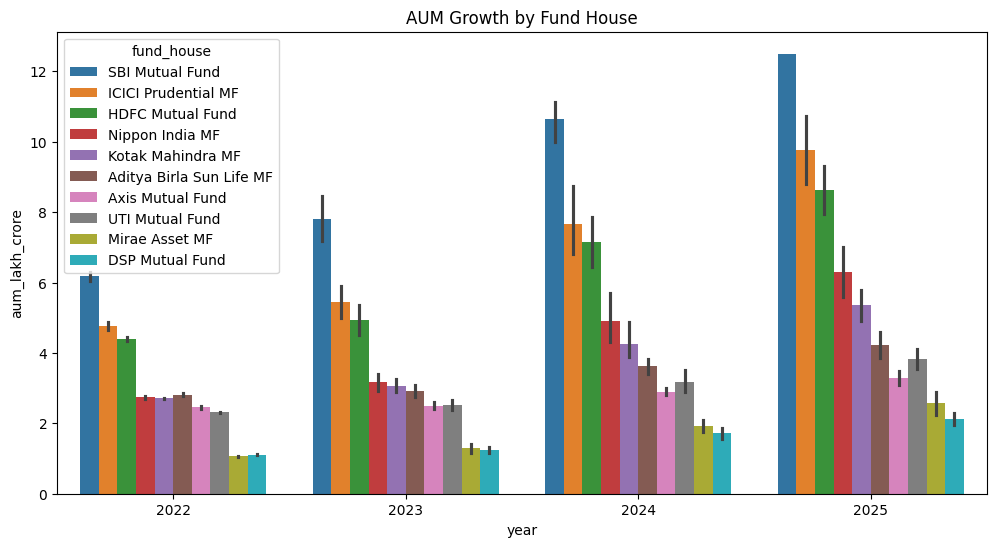

In [3]:
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")

plt.savefig(
    charts / "aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [5]:
sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)

fig.add_annotation(
    x=sip["month"].max().strftime("%Y-%m-%d"),
    y=31002,
    text="₹31,002 Cr ATH",
    showarrow=True
)

fig.write_image(
    charts / "sip_trend.png"
)

fig.show()

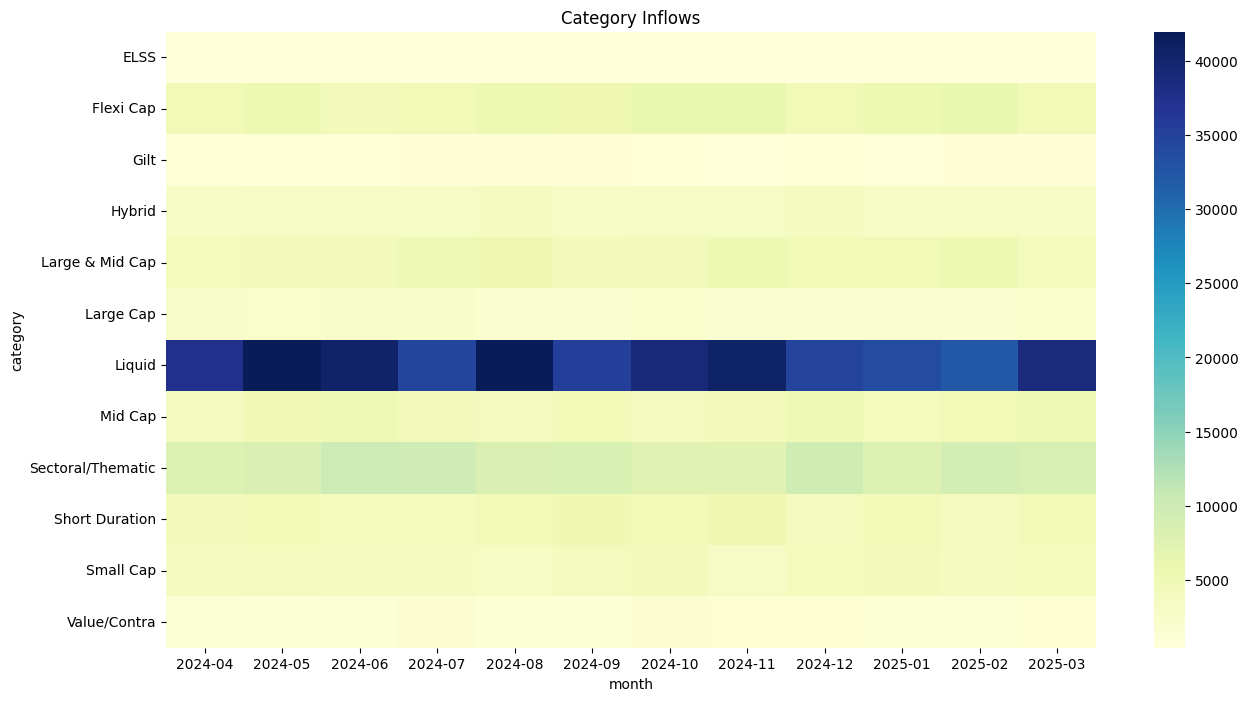

In [6]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.title("Category Inflows")

plt.savefig(
    charts / "category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

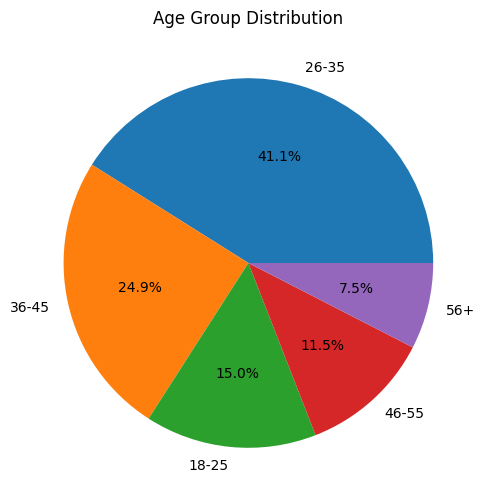

In [7]:
plt.figure(figsize=(6,6))

transactions["age_group"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Age Group Distribution")

plt.savefig(
    charts / "age_distribution.png",
    bbox_inches="tight"
)

plt.show()

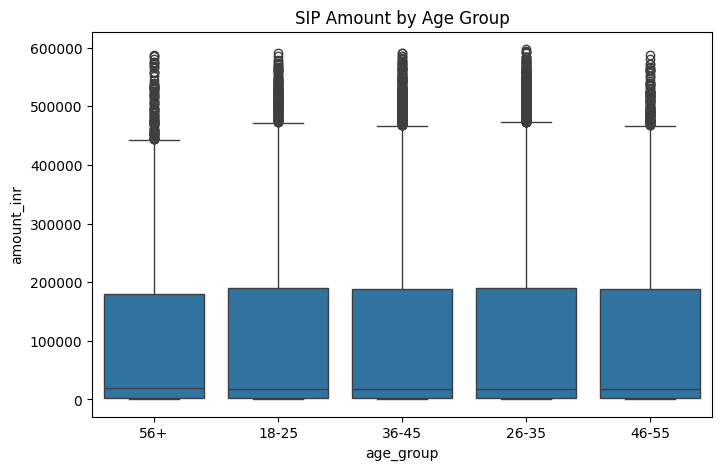

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount by Age Group")

plt.savefig(
    charts / "sip_boxplot_age.png",
    bbox_inches="tight"
)

plt.show()

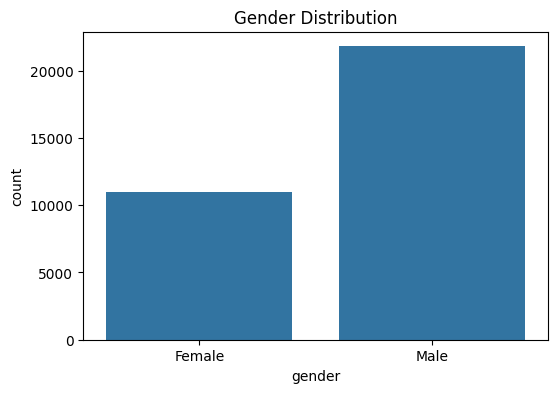

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=transactions,
    x="gender"
)

plt.title("Gender Distribution")

plt.savefig(
    charts / "gender_distribution.png",
    bbox_inches="tight"
)

plt.show()

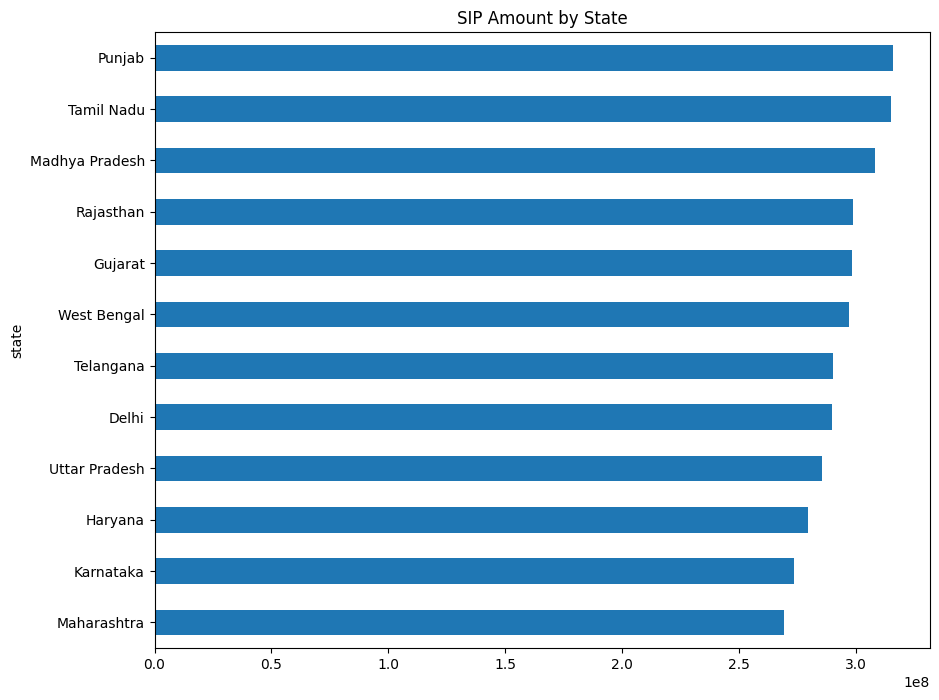

In [10]:
state_sip = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(10,8))

state_sip.plot.barh()

plt.title("SIP Amount by State")

plt.savefig(
    charts / "state_distribution.png",
    bbox_inches="tight"
)

plt.show()

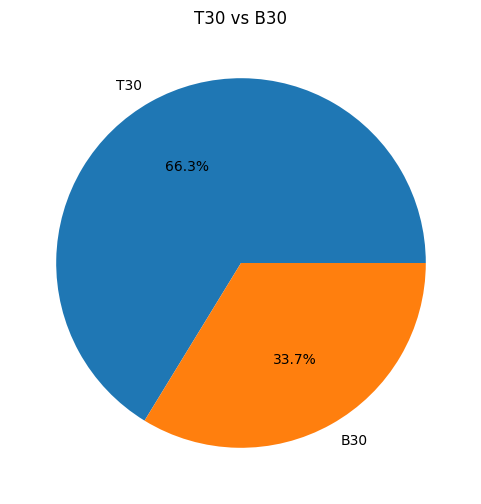

In [11]:
plt.figure(figsize=(6,6))

transactions["city_tier"].value_counts().plot.pie(
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("T30 vs B30")

plt.savefig(
    charts / "city_tier_split.png",
    bbox_inches="tight"
)

plt.show()

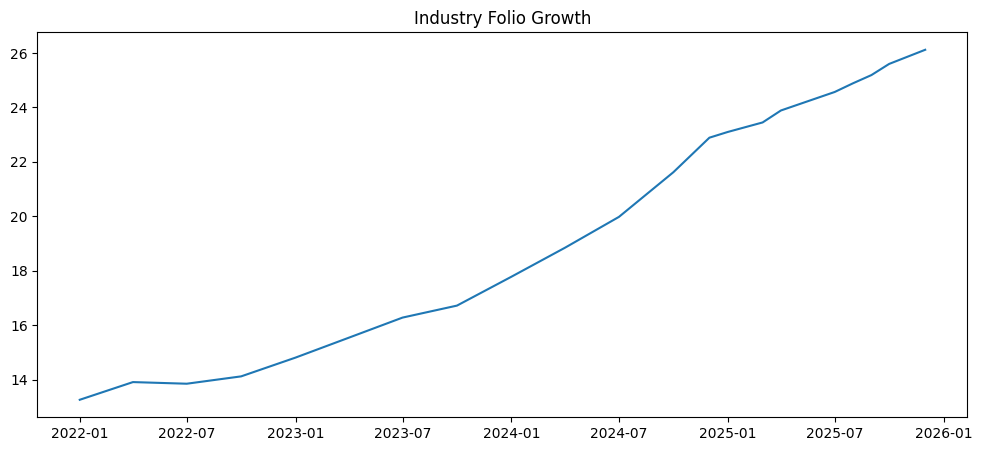

In [12]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.figure(figsize=(12,5))

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)

plt.title("Industry Folio Growth")

plt.savefig(
    charts / "folio_growth.png",
    bbox_inches="tight"
)

plt.show()

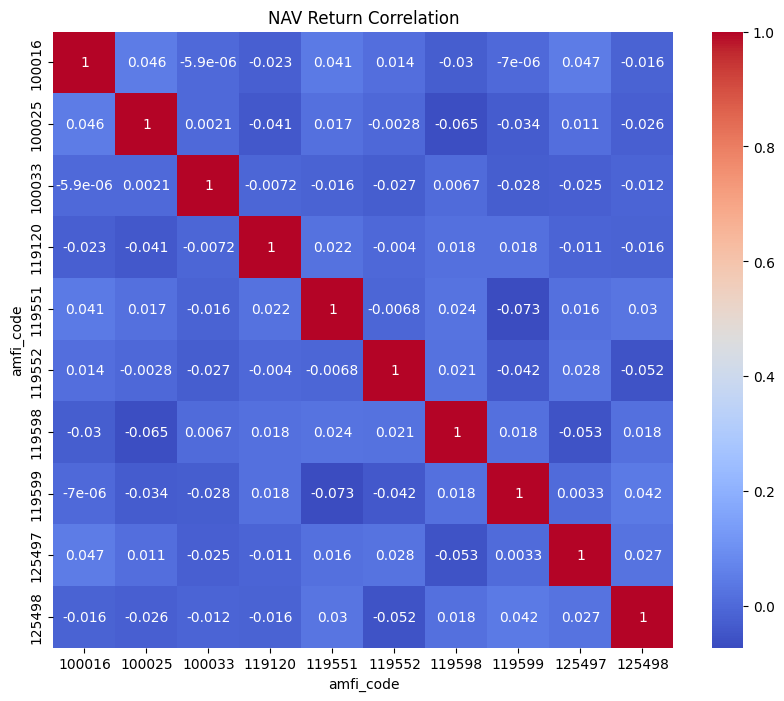

In [13]:
codes = (
    fund_master["amfi_code"]
    .head(10)
    .tolist()
)

corr_df = nav[
    nav["amfi_code"].isin(codes)
]

corr_matrix = (
    corr_df
    .pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
    .pct_change()
    .corr()
)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")

plt.savefig(
    charts / "correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

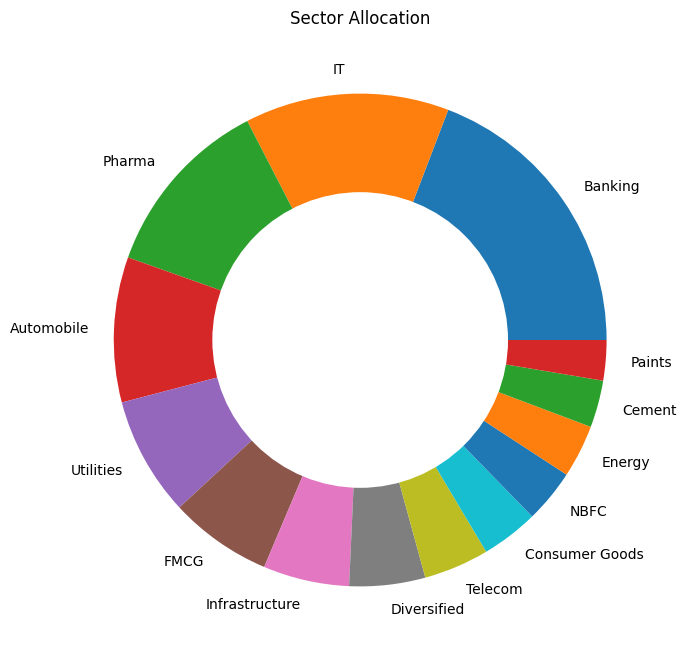

In [14]:
sector = (
    holdings
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index
)

centre = plt.Circle(
    (0,0),
    0.6,
    fc="white"
)

plt.gca().add_artist(centre)

plt.title("Sector Allocation")

plt.savefig(
    charts / "sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

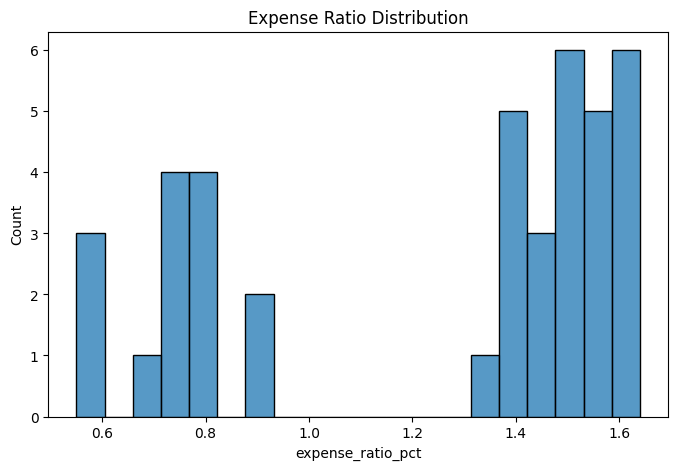

In [15]:
#Expense Ratio Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=20
)

plt.title("Expense Ratio Distribution")

plt.savefig(
    charts / "expense_ratio_distribution.png",
    bbox_inches="tight"
)

plt.show()

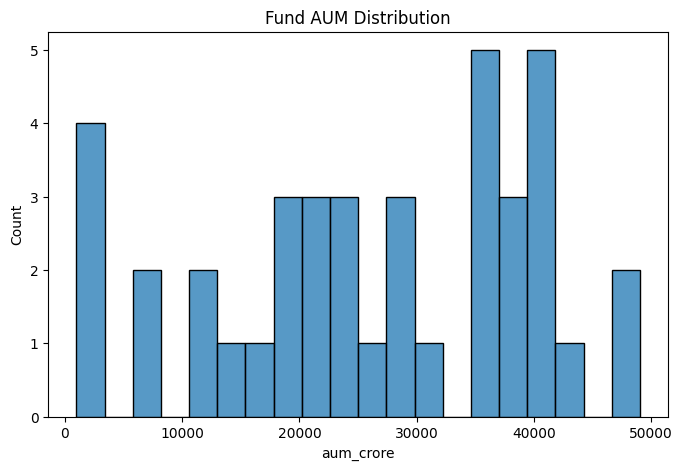

In [16]:
#Fund AUM Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    performance["aum_crore"],
    bins=20
)

plt.title("Fund AUM Distribution")

plt.savefig(
    charts / "aum_distribution.png",
    bbox_inches="tight"
)

plt.show()

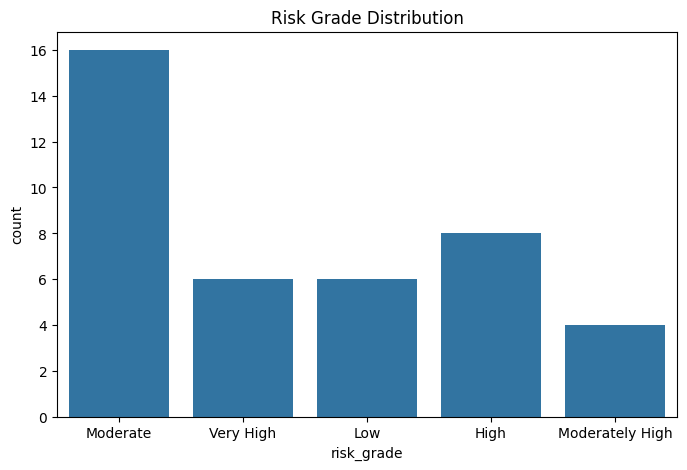

In [17]:
#Risk Grade Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="risk_grade"
)

plt.title("Risk Grade Distribution")

plt.savefig(
    charts / "risk_grade_distribution.png",
    bbox_inches="tight"
)

plt.show()

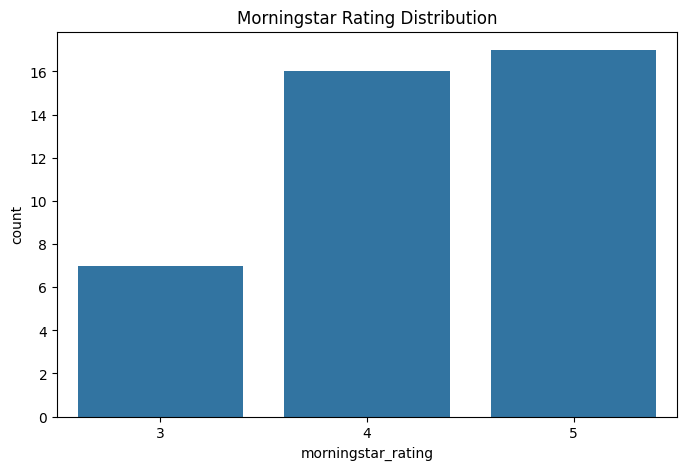

In [18]:
#Morningstar Rating Distribution
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")

plt.savefig(
    charts / "morningstar_distribution.png",
    bbox_inches="tight"
)

plt.show()

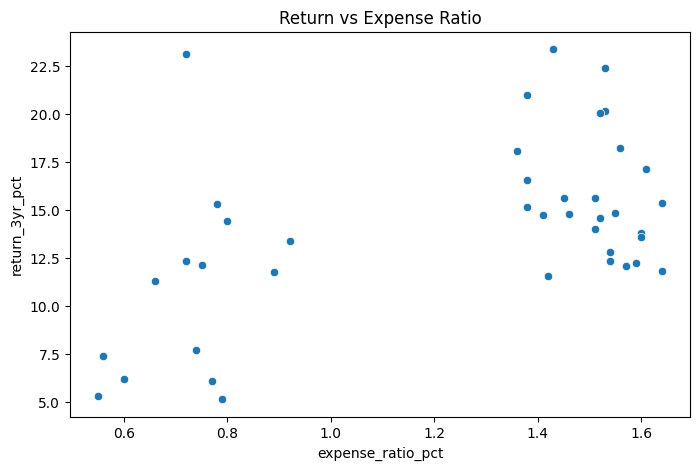

In [19]:
#Return vs Expense Ratio
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=performance,
    x="expense_ratio_pct",
    y="return_3yr_pct"
)

plt.title("Return vs Expense Ratio")

plt.savefig(
    charts / "return_vs_expense.png",
    bbox_inches="tight"
)

plt.show()

Insight 1
Large-cap equity funds showed a steady NAV increase between 2022 and 2026, with stronger growth during the 2023 bull market.
Supporting Chart: NAV Trend Analysis

Insight 2
SBI Mutual Fund maintained the highest AUM among all fund houses throughout the analysis period.
Supporting Chart: AUM Growth by Fund House

Insight 3
Monthly SIP inflows reached an all-time high of ₹31,002 Cr in December 2025.
Supporting Chart: SIP Inflow Trend

Insight 4
Equity-oriented categories attracted significantly higher inflows than debt categories.
Supporting Chart: Category Inflow Heatmap

Insight 5
Investors in the 26–35 age group contributed the largest share of investments.
Supporting Chart: Age Group Distribution

Insight 6
SIP investment amounts varied considerably across age groups.
Supporting Chart: SIP Amount Box Plot

Insight 7
A small number of states accounted for the majority of SIP investments.
Supporting Chart: SIP Amount by State

Insight 8
T30 cities contributed a larger proportion of investments compared to B30 cities.
Supporting Chart: City Tier Distribution

Insight 9
Industry folio count increased substantially from 2022 to 2025, indicating growing retail participation.
Supporting Chart: Folio Count Growth

Insight 10
Large-cap funds exhibited strong positive correlations in daily returns.
Supporting Chart: NAV Correlation Matrix